In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import os #run this if running on a remote server!

os.environ['QT_QPA_PLATFORM'] = 'offscreen'

In [51]:
import sys
sys.path.append('../')
from utility.file_utility import FileUtility

In [52]:
#from data_preprocessing.positive_negative_sampling import DataSampling

#datasampling =DataSampling()
#cluster_ids = datasampling.cluster_sampling

# Running DiMotif step-by-step

<img src="../DiMotif.pdf">

Files containing positive and negative sequences (a sequence per line)

## (i) Sequence segmentation

The segmentation can be applied based on the segmentation learned from Swiss-Prot database (general-purpose) or from the positive set (domain-specific)

### Loading Swiss-Prot Segmentation

We need to load the alpha distribution for segmentation sampling from the file.

In [53]:
import scipy.stats as st
import numpy as np
import tqdm
from utility.math_utility import normalize_mat


swiss_size_change=FileUtility.load_obj('../data_config/swiss_1000_samples.pickle')
all_samples=[]
for i in tqdm.tqdm(range(0,1000)):
    sample=[]
    for vocab in np.arange(10000,1000000,10000):
        sample.append(swiss_size_change[vocab][i])
    all_samples.append(-np.diff(sample))

sample_mat=np.mean(normalize_mat(all_samples),axis=0)
sample_mat_std=np.std(normalize_mat(all_samples),axis=0)
alpha_param = st.alpha.fit(sample_mat)

100%|███████████████████████████████| 1000/1000 [00:00<00:00, 68685.89it/s]


Then we sample from the alpha distribution:

In [54]:
# number of segmentation to be used

segmentation_schemes=10
r = st.alpha.rvs(alpha_param[0], size=segmentation_schemes)
vocab_sizes=np.array(np.round(10000+(r*10000)),dtype=np.int32).tolist()
vocab_sizes.sort()

# vocabulary sizes seen from Swiss-Prot
vocab_sizes

[14416, 14762, 16620, 17179, 18745, 18873, 20063, 25449, 30661, 36589]

In [ ]:
from utility.worker_ppe_utility import multiplex_ppe

ppe_per_id = multiplex_ppe(cluster_ids = 1, vocab_sizes = vocab_sizes, max_workers = 2)

print(ppe_per_id)

number of cores to be used 2
Loaded and processed positive and negative ferredoxin samples for cluster 0Loaded and processed positive and negative ferredoxin samples for cluster 1

Beginning segmentation of sequences in cluster 1Beginning segmentation of sequences in cluster 0



10it [02:50, 17.05s/it]


Completed segmentation of sequences in cluster 0


/home/ss307/miniforge3/envs/dimotif/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
9it [03:06, 20.89s/it]

# In this step we perform segmentation of the ferredoxin sequences based on the steps we have trained already on Swiss-Prot

We pick the SWISS-Prot segmentation for the next steps.

## (ii) Discriminative Motif discovery

Using Chi-square test we find the most significant motifs related to the positive class

## (iii)  Motif visualizations

### Co-occurrences of motifs

Then we look at the co-occurrences pattern of the motifs on the positive set

In [31]:
results = [[('cac', np.float64(0.0)),
 ('dk', np.float64(0.0)),
 ('aw', np.float64(0.0)),
 ('ace', np.float64(0.0)),
 ('tin', np.float64(0.0)),
 ('ky', np.float64(0.0)),
 ('tt', np.float64(0.0)),
 ('ph', np.float64(0.0)),
 ('ip', np.float64(0.0)),
 ('glep', np.float64(0.0)),
 ('ipky', np.float64(0.0)),
 ('mldk', np.float64(0.0))],[('dk', np.float64(1.0)),
 ('aw', np.float64(1.0)),
 ('ace', np.float64(1.0))]]

In [48]:
import csv

with open("output.csv", mode="w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)

    # Optional: Write column headers
    writer.writerow(["kmer", "pval", "cluster"])

    # Write each tuple inside the sublists to the CSV
    for sublist in results:
        writer.writerows(sublist)

In [25]:
# Save to disk
import pickle

with open('./example_vocab_binary.pkl', 'wb') as f:
    pickle.dump(vocab_binary, f)


In [29]:
# Read back
import pickle

with open('./example_vocab_binary.pkl', 'rb') as f:
    vocab_binary = pickle.load(f)

vocab_binary

[('cac', np.float64(0.0)),
 ('dk', np.float64(0.0)),
 ('aw', np.float64(0.0)),
 ('ace', np.float64(0.0)),
 ('tin', np.float64(0.0)),
 ('ky', np.float64(0.0)),
 ('tt', np.float64(0.0)),
 ('ph', np.float64(0.0)),
 ('ip', np.float64(0.0)),
 ('glep', np.float64(0.0)),
 ('ipky', np.float64(0.0)),
 ('mldk', np.float64(0.0))]

### Visualization of co-occurence pattern

In [39]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def create_mat_plot(
    mat,
    axis_names,
    title,
    filename,
    xlab,
    ylab,
    cmap="Blues",
    filetype=".png",
    rx=0,
    ry=0,
    font_s=10,
    annot=True,
):
    """Generates and saves a heatmap for 1D or 2D NumPy arrays without system TeX/dvipng dependencies."""
    # Ensure Matplotlib uses internal rendering (no external TeX/dvipng required)
    plt.rcParams["text.usetex"] = False

    # Convert 1D array to a 2D row matrix (1, N) for Seaborn
    mat = np.atleast_2d(mat)

    plt.figure()

    # Handle tick labels based on matrix dimensions
    if len(axis_names) > 0:
        xtick_labels = (
            axis_names if mat.shape[1] == len(axis_names) else "auto"
        )
        ytick_labels = (
            axis_names if mat.shape[0] == len(axis_names) else False
        )

        ax = sns.heatmap(
            mat,
            annot=annot,
            cmap=cmap,
            xticklabels=xtick_labels,
            yticklabels=ytick_labels,
        )
    else:
        ax = sns.heatmap(mat, annot=annot, cmap=cmap)

    # Set labels and title
    plt.title(title, fontsize=font_s)
    plt.xlabel(xlab, fontsize=font_s)
    plt.ylabel(ylab, fontsize=font_s)

    # Adjust tick font size and rotation
    plt.xticks(fontsize=font_s, rotation=rx)
    plt.yticks(fontsize=font_s, rotation=ry)

    # Save figure
    plt.tight_layout()
    plt.show()
    plt.savefig(f"{filename}.{filetype}", bbox_inches="tight")
    plt.close()

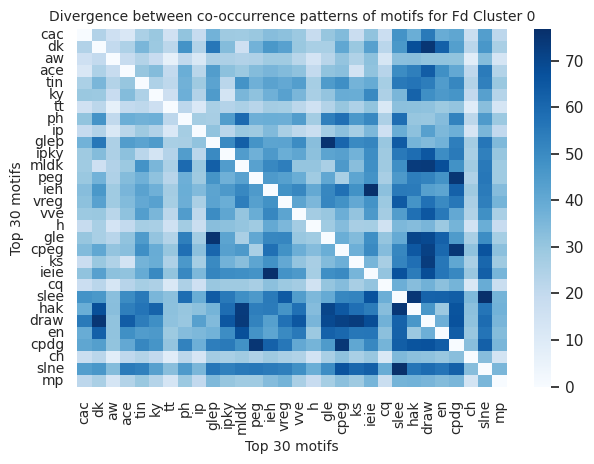

In [42]:
create_mat_plot(DIST[0:30,0:30], [x[0] for x in motifs[0:30]],'Divergence between co-occurrence patterns of motifs for Fd Cluster 0','Biofilm formation','Top 30 motifs','Top 30 motifs',annot=False, rx=90)

## Adding annotations related to secondary structure and other properties

In [43]:
from proteinseq_util.motif_properties import MotifProperties

In [44]:
MotifPropVis=MotifProperties()

In [ ]:
# get most probable structure of this motif in the PDB sequences
MotifPropVis.getMotifStructure('mgl')
#H = alpha helix
#B = residue in isolated beta-bridge
#E = extended strand, participates in beta ladder
#G = 3-helix (3/10 helix)
#I = 5 helix (pi helix)
#T = hydrogen bonded turn
#S = bend
#N = loop or other irregular structure

In [34]:
sec_classes,prop=MotifPropVis.get_motifs_pss_biophys(['mgl'])

100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 9078.58it/s]


In [35]:
prop
# The order is the normalized
#['mean_molecular_weight',
# 'mean_flexibility',
# 'instability',
# 'mean_surface_accessibility',
# 'mean_kd_hydrophobicity',
# 'mean_hydrophilicity']

{'mgl': [-1.0114634864612668,
  np.float64(-0.28252406036752725),
  np.float64(-0.28258896805474465),
  np.float64(-0.970740175139044),
  np.float64(0.7751299216012043),
  np.float64(-0.4360941592403529)]}

#### if you have ete3 installed you can get the tree visualization as well

In [45]:
from proteinseq_util.motif_tree_visualization import VisualizeTreeOfMotifs

In [46]:
VT=VisualizeTreeOfMotifs(tree,[x[0] for x in motifs])

VT.create_circle('../datasets/'+'/biofilm_prop.pdf', 'BioFilm tree of motifs', ignore_branch_length=True)

  0%|                                                                                            | 0/50 [00:00<?, ?it/s]/home/ss307/.conda/envs/sci-env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ss307/.conda/envs/sci-env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 31808.77it/s]


<img src="biofilm_prop.pdf">